In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# ۱. تنظیم مسیر داده‌های تست (بر اساس ساختار دیتاست Kaggle)
TEST_DATA_DIR = '../data/human-and-non-human/test_set'
IMG_SIZE = 96
BATCH_SIZE = 32

# ۲. بارگذاری مدل آموزش دیده
model = tf.keras.models.load_model('human_detection_base.keras')

# ۳. تابع نرمال‌سازی
def process_data(image, label):
    return image / 255.0, label

# ۴. بارگذاری داده‌های تست
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=True # برای تست بصری بهتر است به هم ریخته باشد
)

# اعمال نرمال‌سازی روی داده‌های تست
test_dataset = test_dataset.map(process_data).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# ۵. محاسبه دقت مدل
print("\nدر حال ارزیابی مدل روی داده‌های تست...")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"\nدقت مدل روی داده‌های دیده‌نشده (Test Accuracy): {test_acc * 100:.2f}%")

Found 2723 files belonging to 2 classes.

در حال ارزیابی مدل روی داده‌های تست...
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9941 - loss: 0.0162

دقت مدل روی داده‌های دیده‌نشده (Test Accuracy): 99.41%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


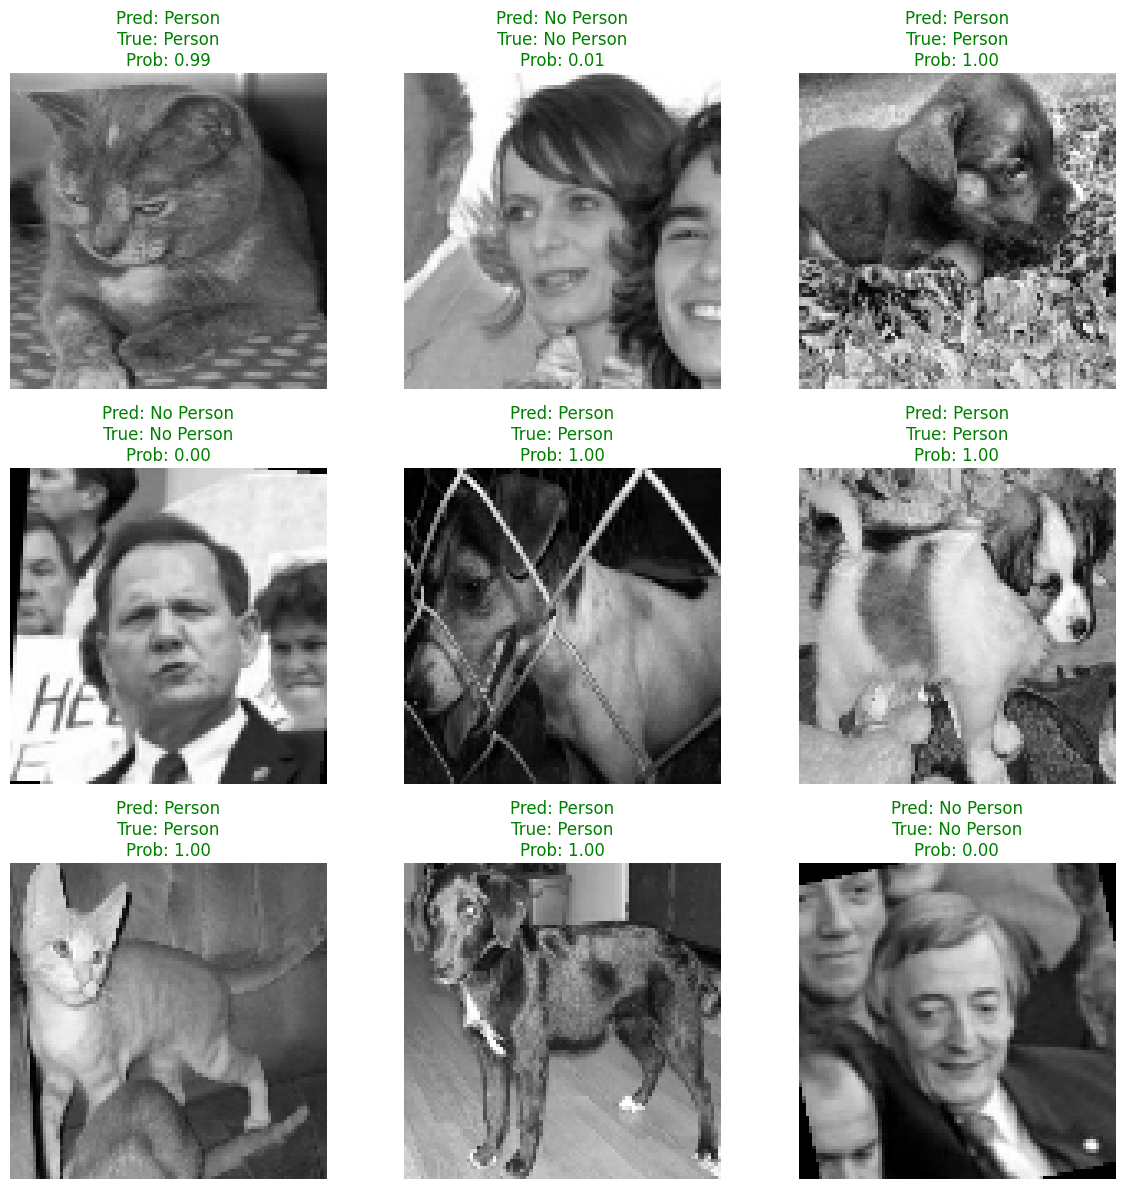

In [9]:
# گرفتن یک بچ (۳۲ عدد) از داده‌های تست
image_batch, label_batch = next(iter(test_dataset))

# گرفتن پیش‌بینی مدل برای این ۳۲ عکس
# خروجی مدل عددی بین 0 و 1 است (احتمال وجود انسان)
predictions = model.predict(image_batch)

class_names = ['No Person', 'Person']

plt.figure(figsize=(12, 12))
for i in range(9): # نمایش ۹ عکس اول از این بچ
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(tf.squeeze(image_batch[i]), cmap='gray')
    
    # تبدیل احتمال به برچسب 0 یا 1 (اگر بزرگتر از 0.5 بود یعنی انسان است)
    predicted_label = 1 if predictions[i][0] > 0.5 else 0
    true_label = int(label_batch[i].numpy())
    
    # اگر پیش‌بینی درست بود رنگ سبز، اگر غلط بود رنگ قرمز
    color = 'green' if predicted_label == true_label else 'red'
    
    title = f"Pred: {class_names[predicted_label]}\nTrue: {class_names[true_label]}\nProb: {predictions[i][0]:.2f}"
    plt.title(title, color=color)
    plt.axis("off")
    
plt.tight_layout()
plt.show()

In [11]:
import tensorflow as tf
import numpy as np

# ۱. تنظیم مسیر داده‌های تست (مثل قبل)
TEST_DATA_DIR = '../data/human-and-non-human/test_set'
IMG_SIZE = 96

# بارگذاری دیتاست تست با بچ‌سایز ۱ (چون مدل TFLite عکس‌ها را تک‌تک پردازش می‌کند)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1, 
    color_mode="grayscale",
    shuffle=False # نیازی به برهم‌زدن برای محاسبه دقت کلی نیست
)

# ۲. راه‌اندازی مفسر TFLite
interpreter = tf.lite.Interpreter(model_path="model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

input_scale, input_zero_point = input_details['quantization']
output_scale, output_zero_point = output_details['quantization']

# متغیرهایی برای شمارش پیش‌بینی‌های درست
correct_predictions = 0
total_images = 0

print("\nشروع ارزیابی مدل ۸-بیتی روی دیتاست تست... (ممکن است کمی زمان ببرد)")

# ۳. حلقه روی تک‌تک تصاویر دیتاست تست
for images, labels in test_dataset:
    # الف) نرمال‌سازی تصویر (۰ تا ۱)
    image_normalized = images.numpy() / 255.0
    
    # ب) کوانتیزاسیون تصویر (تبدیل به Int8)
    if input_scale != 0.0:
        input_data = (image_normalized / input_scale) + input_zero_point
        input_data = np.round(input_data)
        input_data = np.clip(input_data, -128, 127).astype(np.int8)
    else:
        input_data = (image_normalized * 255 - 128).astype(np.int8)
    
    # ج) اجرای مدل (Inference)
    interpreter.set_tensor(input_details['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details['index'])
    
    # د) تبدیل خروجی ۸-بیتی به درصد
    if output_scale != 0.0:
        probability = (output_data[0][0] - output_zero_point) * output_scale
    else:
        probability = (output_data[0][0] + 128) / 255.0
        
    # ه) بررسی درستی پیش‌بینی
    predicted_label = 1 if probability > 0.5 else 0
    true_label = int(labels.numpy()[0])
    
    if predicted_label == true_label:
        correct_predictions += 1
        
    total_images += 1
    # بعد از به دست آوردن probability این خط را اضافه کن:
    print(f"احتمال خروجی مدل: {probability:.3f}")

# ۴. محاسبه و چاپ نتیجه نهایی
accuracy = (correct_predictions / total_images) * 100
print("-" * 50)
print(f"تعداد کل تصاویر تست شده: {total_images}")
print(f"تعداد تشخیص‌های درست: {correct_predictions}")
print(f"دقت نهایی مدل کوانتایز شده (TFLite Int8 Accuracy): {accuracy:.2f}%")

Found 2723 files belonging to 2 classes.

شروع ارزیابی مدل ۸-بیتی روی دیتاست تست... (ممکن است کمی زمان ببرد)
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.113
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.016
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.113
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احت

C:\Users\User\AppData\Local\Temp\ipykernel_49760\2683275337.py:53: RuntimeWarning: overflow encountered in scalar subtract
  probability = (output_data[0][0] - output_zero_point) * output_scale


احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.008
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: -0.129
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.016
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مدل: 0.000
احتمال خروجی مد

In [4]:
import cv2
import numpy as np
import tensorflow as tf

# ۱. راه‌اندازی مفسر TFLite و بارگذاری مدل فشرده‌شده
interpreter = tf.lite.Interpreter(model_path="model.tflite")
interpreter.allocate_tensors()

# گرفتن اطلاعات ورودی و خروجی مدل برای کوانتیزاسیون
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

# استخراج مقیاس (Scale) و نقطه صفر (Zero Point) برای تبدیل عکس اعشاری به ۸-بیتی
input_scale, input_zero_point = input_details['quantization']
output_scale, output_zero_point = output_details['quantization']

# ۲. روشن کردن وب‌کم (عدد 0 معمولاً دوربین اصلی لپ‌تاپ است)
cap = cv2.VideoCapture(0)

print("دوربین روشن شد. برای خروج دکمه 'q' را فشار دهید.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("خطا در خواندن تصویر از دوربین!")
        break
        
    # ۳. پیش‌پردازش تصویر (دقیقاً مشابه چیزی که در آموزش داشتیم)
    # الف) برش تصویر به شکل مربع (برای جلوگیری از کشیدگی چهره)
    h, w, _ = frame.shape
    min_dim = min(h, w)
    start_x = (w - min_dim) // 2
    start_y = (h - min_dim) // 2
    cropped_frame = frame[start_y:start_y+min_dim, start_x:start_x+min_dim]
    
    # ب) تغییر سایز به ۹۶ در ۹۶ و سیاه‌سفید کردن
    resized = cv2.resize(cropped_frame, (96, 96))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    
    # ج) نرمال‌سازی (۰ تا ۱)
    normalized = gray / 255.0
    
    # ۴. تبدیل تصویر به فرمت Int8 (مخصوص مدل کوانتایز شده)
    if input_scale != 0.0:
        input_data = (normalized / input_scale) + input_zero_point
        input_data = np.clip(input_data, -128, 127).astype(np.int8)
    else:
        input_data = (normalized * 255 - 128).astype(np.int8)
        
    # اضافه کردن بعدهای لازم تا شکل ماتریس بشود (1, 96, 96, 1)
    input_data = np.expand_dims(input_data, axis=[0, 3])
    
    # ۵. اجرای مدل (Inference)
    interpreter.set_tensor(input_details['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details['index'])
    
    # ۶. برگرداندن خروجی مدل از ۸-بیتی به درصد اعشاری
    if output_scale != 0.0:
        probability = (output_data[0][0] - output_zero_point) * output_scale
    else:
        probability = (output_data[0][0] + 128) / 255.0

    # ۷. نمایش نتیجه روی تصویر
    label = "Person" if probability > 0.5 else "No Person"
    color = (0, 255, 0) if probability > 0.5 else (0, 0, 255) # سبز برای انسان، قرمز برای غیر انسان
    
    # چاپ متن روی تصویر اصلی وب‌کم
    cv2.putText(frame, f"{label} ({probability:.2f})", (20, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)
                
    # نمایش تصویر وب‌کم
    cv2.imshow('TFLite Quantized Model - Webcam Test', frame)
    
    # با زدن دکمه 'q' روی کیبورد از حلقه خارج می‌شویم
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# خاموش کردن دوربین و بستن پنجره‌ها
cap.release()
cv2.destroyAllWindows()

c:\Users\User\anaconda3\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


دوربین روشن شد. برای خروج دکمه 'q' را فشار دهید.


C:\Users\User\AppData\Local\Temp\ipykernel_49760\55028331.py:60: RuntimeWarning: overflow encountered in scalar subtract
  probability = (output_data[0][0] - output_zero_point) * output_scale
